<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
What is Twitter Sentiment Analysis?
</span>
</h2>
Twitter sentiment analysis is a Natural Language Processing (NLP) technique used to determine whether a tweet expresses a positive or negative sentiment. It analyzes text data from tweets and classifies them using machine learning algorithms. This helps organizations understand public opinion and customer feedback.

<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Objective
</span>
</h2>
The main objective of this project is to analyze Twitter data and classify tweets into positive or negative sentiments using NLP techniques and machine learning models.


<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
NLP Pipeline
</span>
</h2>

1. Data Collection  
2. Text Wrangling and Preprocessing  
3. Vectorization and Feature Engineering  
4. Model Building and Initialization  
5. Train and Test Model  
6. Model Evaluation  
7. Deployment  
8. Monitoring and Model Updating

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Import Packages
</span>
</h3>

In [1]:
pip install contractions


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
!pip install unidecode

Defaulting to user installation because normal site-packages is not writeable


In [25]:
import nltk


<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Import Libraries 
</span>
</h3>

In [1]:
# data handling
import pandas as pd
import numpy as np
import nltk

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# text processing
import re
import string
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from unidecode import unidecode
from nltk.tokenize import RegexpTokenizer

import string, nltk, contractions
from string import punctuation
from unidecode import unidecode
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,  PorterStemmer
from nltk.stem import SnowballStemmer

from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB

nltk.download('stopwords')

# machine learning
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\archi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Load Dataset
</span>
</h3>

In [2]:
# here we create a list of our column name 
columns_name = ["target","id","date","flag","user","text"]

# here we give a column name that is given in columns_name 

final_df = pd.read_csv(r"training.1600000.processed.noemoticon.csv",
                 names=columns_name,encoding="ISO-8859-1")
final_df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Dataset Description
</span>
</h3>

This dataset contains **1,600,000 rows and 6 columns** with information about tweets and their sentiments. The columns are as follows:

| Column | Description |
|------|-------------|
| target | The polarity of the tweet, indicating whether it is **positive or negative**. |
| ids | A unique identifier for each tweet. |
| date | The date when the tweet was posted. |
| flag | Refers to the query type. If no specific query exists, this field shows **NO QUERY**. |
| user | The username of the person who tweeted. |
| text | The content of the tweet. |

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Exploratory Data Analysis
</span>
</h3>

Exploratory Data Analysis is performed to understand the dataset and identify patterns in the data. It includes checking dataset structure, missing values, and distribution of sentiment classes.

In [6]:
# Here we check the shape of dataset
final_df.shape

(1600000, 6)

##### summary :
The dataset shape provides information about the total number of rows and columns present in the dataset. From the output, we can observe that the dataset contains 1,600,000 rows and 6 columns, which indicates a large amount of tweet data available for analysis. A dataset of this size is beneficial for building a reliable sentiment analysis model because it provides sufficient examples for both positive and negative sentiments.

In [7]:
# Here we check the info  
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


##### summary :
The dataset information displays the structure of the dataset, including column names, data types, and the number of non-null values. This step helps us understand how the data is stored and whether each column contains valid entries. From the output, we can see that all columns contain valid data and there are no missing values present in the dataset.

In [41]:
# here we check missing values
final_df.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

##### summary :
Checking for missing values is an important step in Exploratory Data Analysis. Missing values can negatively affect the performance of machine learning models if they are not handled properly. In this dataset, the output shows that there are no missing values in any column, which means the dataset is clean and ready for further processing.

In [42]:
# here we check duplicate values
final_df.duplicated().sum()

np.int64(0)

##### summary :
Duplicate values occur when the same record appears multiple times in the dataset. These duplicates can affect the accuracy of data analysis and machine learning models. Therefore, it is important to check whether duplicate records exist in the dataset. By checking duplicates, we ensure that the dataset contains unique records and maintains data quality.

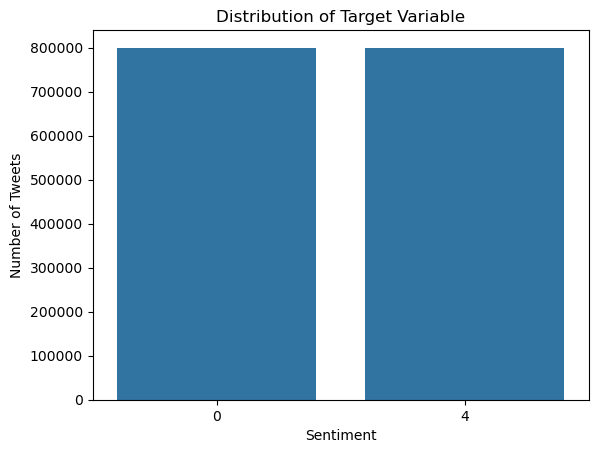

In [43]:
sns.countplot(x='target', data=final_df)

plt.title("Distribution of Target Variable")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

##### Target Variable Details :

The target column represents the sentiment of tweets in the dataset.

0 → Negative sentiment

4 → Positive sentiment

This column is used as the output variable for training the sentiment analysis model.

##### Summary : 

The Exploratory Data Analysis shows that the dataset contains a large number of tweets with clearly defined sentiment labels. The dataset does not contain missing values and provides a balanced distribution of positive and negative tweets. This makes it suitable for building a machine learning model for sentiment classification.

<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Final EDA Summary :
</span>
</h2>

Exploratory Data Analysis was conducted to understand the dataset structure and identify important characteristics of the data. The dataset contains a large number of tweets with clearly defined sentiment labels. No missing values were found in the dataset, which indicates that the data is complete. Duplicate records were also checked to maintain data quality. Finally, the distribution of the target variable was visualized to understand the number of positive and negative tweets in the dataset. This analysis helps prepare the data for building an accurate sentiment analysis model.

<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Developing a Sentiment Classification Model using NLP
</span>
</h2>

In [3]:
# Here we make a new column in which dependent("target") and independent("text") variable is stored.
tweets_df = final_df[['text','target']]
tweets_df.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [23]:
# Here we replace the 4 TO 1 for batter understanding of "target" 
tweets_df['target'] = tweets_df['target'].replace(4, 1)

In [24]:
tweets_df['target'].unique()

array([0, 1])

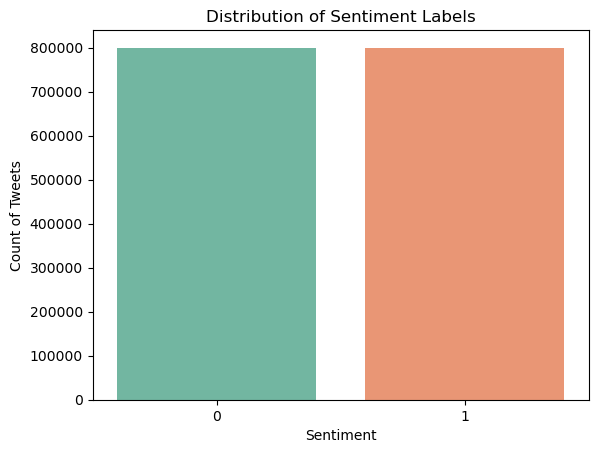

In [25]:
# Here we again use the countplot to check the "target" column
sns.countplot(x='target', data=tweets_df, palette='Set2')

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count of Tweets")

plt.show()

In [4]:
# Here we convert "text" column into lower string 
tweets_df['text'] = tweets_df['text'].str.lower()
tweets_df['text'].head()

0    @switchfoot http://twitpic.com/2y1zl - awww, t...
1    is upset that he can't update his facebook by ...
2    @kenichan i dived many times for the ball. man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
Name: text, dtype: object

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Important Text Preprocessing Concepts in NLP
</span>
</h3>

#### Stop Words Removal :

In Natural Language Processing, stop words refer to frequently used words such as “the”, “is”, “a”, “in”, and “and”. These words appear very often in sentences but usually do not contribute much meaning when analyzing text.

Because of this, many NLP applications remove stop words to reduce noise in the data. Eliminating these words helps the model focus on more informative terms that actually contribute to understanding sentiment or topic.

#### Handling Punctuation :

Punctuation symbols like periods, commas, question marks, and exclamation marks are often removed during text preprocessing. Removing punctuation helps simplify the text and reduces unnecessary characters in the dataset.

However, in some cases punctuation can carry useful information. For example, an exclamation mark may express strong emotion or excitement in a tweet. Therefore, depending on the task, punctuation may either be removed or retained.

#### Tokenization :

Tokenization is the process of breaking text into smaller units such as words or sentences. These smaller pieces are called tokens. Tokenization is an important step because it allows computers to analyze text more easily.

There are different forms of tokenization:

1) Word Tokenization – splitting text into individual words

2) Sentence Tokenization – dividing text into separate sentences

3) Tweet Tokenization – specialized tokenization for social media text

4) Custom Tokenization – using regular expressions to create specific token patterns

#### Stemming and Lemmatization :

Stemming and lemmatization are techniques used to normalize words by converting them to their root form. This helps reduce variations of the same word so the model can process text more efficiently.

##### Stemming ->

Stemming is a rule-based process that removes prefixes or suffixes from words to obtain their base form. For example, words like “running”, “runner”, and “runs” may all be reduced to “run”. This method is fast but sometimes produces words that are not linguistically correct.

##### Lemmatization ->

Lemmatization converts a word to its dictionary form (lemma) by considering its meaning and grammatical structure. For instance, “running” and “ran” are both converted to “run”. Although lemmatization is more accurate than stemming, it requires more computational effort.

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Text Normalization and Cleaning Functions
</span>
</h3>

In [5]:
# (1️) Removing Unwanted Spaces and Line Breaks
def normalize_whitespace(text):
    cleaned = text.replace('\n',' ').replace('\t',' ')
    cleaned = cleaned.replace('\\',' ')
    return cleaned

# Summary -> This function removes unwanted newline characters, tab spaces, and backslashes from the text.
#            Cleaning these characters ensures that the tweet text appears as a continuous and readable sentence.

In [6]:
# (2) Expanding Contracted Words
def expand_contractions(text):
    expanded = contractions.fix(text)
    return expanded

# Summary -> Many tweets contain shortened words such as “can't”, “won't”, or “I'm”.
#            This function converts these contractions into their full forms so the text becomes easier to analyze.

In [7]:
# (3) Converting Accented Characters
def remove_accent_characters(text):
    normalized = unidecode(text)
    return normalized

# Summary -> Some tweets may contain accented or special characters.
#            This function converts those characters into standard English characters to maintain consistency in the dataset.

In [8]:
# (4) Eliminating Stopwords
STOP_WORDS = set(stopwords.words("english"))

def remove_stop_words(sentence):
    filtered_words = [
        word for word in str(sentence).split()
        if word.lower() not in STOP_WORDS
    ]
    return " ".join(filtered_words)

# Summary -> Stopwords are very common words that usually do not contribute much meaning to text analysis.
#            Removing them helps the model focus on more informative words that influence sentiment.

In [9]:
# (5) Removing Punctuation Symbols
def strip_punctuation(text):
    table = str.maketrans('', '', string.punctuation)
    return text.translate(table)

# Summary -> Tweets often contain punctuation marks that are not always useful for machine learning models.
#            This function removes those characters to simplify the text.

In [10]:
# (6) Removing Numbers
def remove_digits(text):
    return re.sub(r'\d+', '', text)

# Summary -> Numbers are usually not useful for sentiment classification tasks.
#            This step removes all numeric values from the tweet text.

In [11]:
# (7) Removing URLs
def remove_links(text):
    pattern = r"(https?://\S+|www\.\S+)"
    return re.sub(pattern, '', text)

# Summary -> Tweets frequently contain links to external websites.
#            Since URLs usually do not contribute to sentiment analysis, they are removed from the text.

In [12]:
# (8) Optional Spelling Correction
def correct_spelling(text):
    spell = Speller(lang='en')
    return spell(text)

# Summary -> Sometimes tweets contain spelling mistakes or informal words.
#            This function can automatically correct spelling errors to improve text quality.

In [13]:
# (9) Tokenization and Basic Cleaning
def tokenize_text(text):
    tokens = word_tokenize(text)
    
    processed_tokens = [
        word.lower()
        for word in tokens
        if word.isalpha() and len(word) > 1
    ]
    
    return processed_tokens

# Summary -> Tokenization breaks text into individual words called tokens.
#            This step also converts words to lowercase and removes non-alphabetic characters.

In [14]:
# (10) Applying Stemming
def apply_stemming(words):
    stemmer = SnowballStemmer("english")
    stems = [stemmer.stem(word) for word in words]
    
    return " ".join(stems)

# Summary -> Stemming reduces words to their root form by removing prefixes or suffixes.
#            This helps group similar words together and reduces vocabulary size.

In [15]:
# (11) Applying Lemmatization
def apply_lemmatization(words):
    lemmatizer = WordNetLemmatizer()
    
    lemmas = [
        lemmatizer.lemmatize(word)
        for word in words
    ]
    
    return " ".join(lemmas)

# Summary -> Lemmatization converts words into their dictionary form based on their meaning.
#            Unlike stemming, it produces linguistically correct words and improves text consistency.

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Text Cleaning and Transformation Pipeline
</span>
</h3>

In [17]:
# -------------------- TEXT PREPROCESSING PIPELINE -------------------- #

# Step 1: Normalize whitespace characters
tweets_df["text"] = tweets_df["text"].apply(normalize_whitespace)
print("Whitespace normalization finished")


# Step 2: Convert contracted words into full forms
tweets_df["text"] = tweets_df["text"].apply(expand_contractions)
print("Contraction expansion completed")


# Step 3: Convert accented characters to standard form
tweets_df["text"] = tweets_df["text"].apply(remove_accent_characters)
print("Accent normalization applied")


# Step 4: Filter out stop words
tweets_df["text"] = tweets_df["text"].apply(remove_stop_words)
print("Stop words filtered successfully")


# Step 5: Remove punctuation marks
tweets_df["text"] = tweets_df["text"].apply(strip_punctuation)
print("Punctuation symbols removed")


# Step 6: Eliminate URLs from tweets
tweets_df["text"] = tweets_df["text"].apply(remove_links)
print("URL removal step completed")


# Step 7: Remove digits from text
tweets_df["text"] = tweets_df["text"].apply(remove_digits)
print("Numeric characters removed")


# Step 8: Tokenize the tweet text
tokenizer = RegexpTokenizer(r"\w+")
tweets_df["text"] = tweets_df["text"].apply(tokenizer.tokenize)
print("Tokenization step completed")


# Step 9: Perform stemming
tweets_df["text"] = tweets_df["text"].apply(apply_stemming)
print("Stemming applied to tokens")

# -------------------------------------------------------------------- #


Whitespace normalization finished
Contraction expansion completed
Accent normalization applied
Stop words filtered successfully
Punctuation symbols removed
URL removal step completed
Numeric characters removed
Tokenization step completed
Stemming applied to tokens


###### Summary ->
This preprocessing pipeline cleans and standardizes tweet text before it is used for model training. The steps include removing unnecessary whitespace, expanding contractions, normalizing accented characters, eliminating stopwords, removing punctuation, filtering URLs and numbers, tokenizing the text, and finally applying stemming to reduce words to their root form.

In [20]:
# Here we check the "text" column
tweets_df['text']

0          switchfoot httptwitpiccomyzl awww bummer shoul...
1          upset cannot updat facebook text might cri res...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                       nationwideclass behav mad cannot see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdbcom cool hear old walt interview httpbli...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: text, Length: 1600000, dtype: object

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Visualizing Frequent Words using Word Cloud
</span>
</h3>

Word Cloud is a visual method used to show the most frequently occurring words in a text dataset. Words that appear more often are displayed in larger sizes, while less frequent words appear smaller. It helps quickly identify important terms in large text data such as tweets or reviews. In this analysis, a word cloud is created for negative tweets to highlight commonly used words related to negative sentiment.

##### Word Cloud Visualization for Positive Tweets

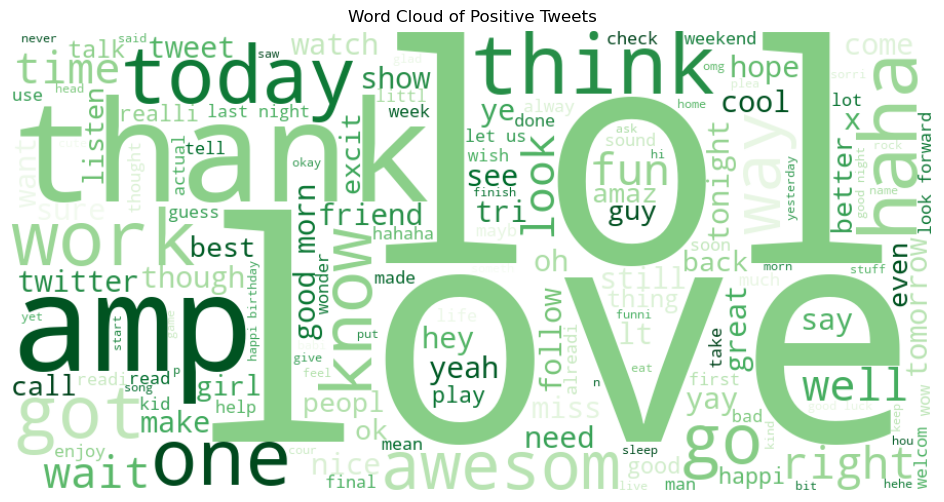

In [30]:
# ---------------- WORD CLOUD FOR POSITIVE TWEETS ---------------- #

# Filter positive tweets
positive_tweets = tweets_df[tweets_df["target"] == 1]

# Combine tweet text into one string
positive_text = " ".join(positive_tweets["text"].dropna().astype(str))

# Create word cloud
positive_wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Greens",
    max_words=150
).generate(positive_text)

# Display word cloud
plt.figure(figsize=(12,6))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")

plt.title("Word Cloud of Positive Tweets")

plt.show()

###### Summary ->

This word cloud visualization represents the most commonly used words in tweets with positive sentiment. Words that appear more frequently in positive tweets are displayed in larger font sizes, while less frequent words appear smaller. This visualization helps identify the common vocabulary used when users express positive opinions or experiences in their tweets.

##### Word Cloud Visualization for Negative Tweets

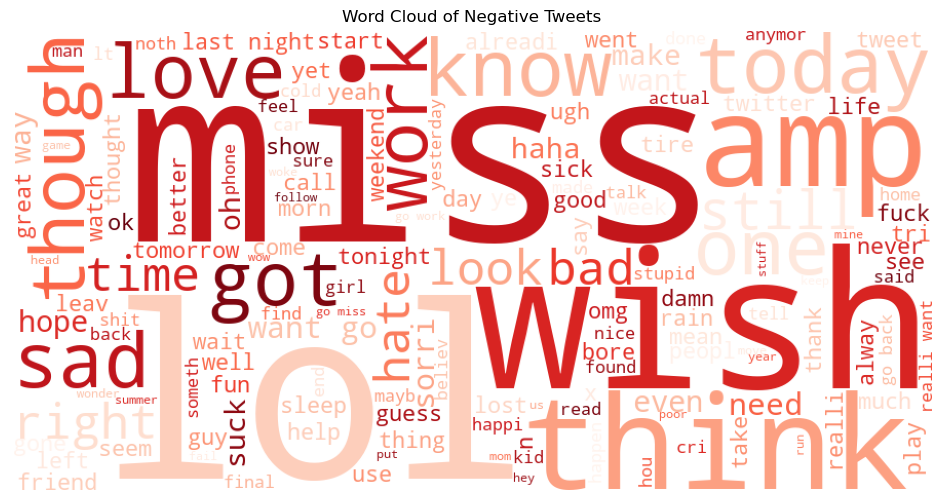

In [31]:
# ---------------- WORD CLOUD FOR NEGATIVE TWEETS ---------------- #

# Filter negative tweets
negative_tweets = tweets_df[tweets_df["target"] == 0]

# Combine all tweet text into one string
negative_text = " ".join(negative_tweets["text"])

# Generate word cloud
negative_wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="Reds",
    max_words=150
).generate(negative_text)

# Plot the word cloud
plt.figure(figsize=(12,6))
plt.imshow(negative_wc)
plt.axis("off")

plt.title("Word Cloud of Negative Tweets")

plt.show()

###### Summary -> 

This visualization displays the most frequently occurring words in tweets with negative sentiment. The word cloud highlights the terms that appear most often in negative tweets by increasing their font size. Larger words indicate higher frequency, while smaller words represent less common terms. This helps identify patterns and commonly used expressions associated with negative opinions in the dataset.

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model Insights and Interpretation
</span>
</h3>

In [32]:
# Here we make two new varable df_x (dependent) and df_y (independent) 
df_x = tweets_df['text']
df_y = tweets_df['target']

In [33]:
# Here we use the train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size = 0.25, random_state = 286348, stratify=df_y)

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
TF-IDF Vectorizer
</span>
</h4>




- TF-IDF (Term Frequency–Inverse Document Frequency) is a technique used in Natural Language Processing to measure the importance of words in a document.

- Term Frequency (TF) calculates how often a word appears in a document.

- Inverse Document Frequency (IDF) measures how rare a word is across all documents.

- Words with higher TF-IDF scores are considered more important for representing the content of a document.

- It is commonly used in tasks such as text classification, sentiment analysis, and information retrieval.

In [34]:
# TF-IDF Vectorization

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    stop_words='english'
)

# Transform training data
X_train_tfidf = vectorizer.fit_transform(x_train)

# Count total feature words
num_features = len(vectorizer.get_feature_names_out())

# Display number of features
print("Number of feature words:", num_features)

Number of feature words: 50000


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=50000, stop_words='english')

# Fit on training data
x_train_tfidf = vectoriser.fit_transform(x_train)

# Transform test data
x_test_tfidf = vectoriser.transform(x_test)

###### Summary -> 

This code applies the TF-IDF Vectorizer to convert the training text data into numerical features. It considers both unigrams and bigrams, removes common English stop words, and limits the feature size to 50,000 important terms. The training data is then transformed into a TF-IDF matrix, and the total number of generated feature words is displayed.

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model 1 : Naive Bayes
</span>
</h4>


In [39]:
print("\nTraining Bernoulli Naive Bayes...")

bnb_model = BernoulliNB()
bnb_model.fit(x_train_tfidf, y_train)

# Predict on the training set
y_train_pred_bnb = bnb_model.predict(x_train_tfidf)

# Print evaluation metrics for Bernoulli Naive Bayes
print("Bernoulli Naive Bayes Accuracy Score: \n", accuracy_score(y_train, y_train_pred_bnb))
print("Bernoulli Naive Bayes Confusion Matrix: \n", confusion_matrix(y_train, y_train_pred_bnb))
print("Bernoulli Naive Bayes Classification Report: \n", classification_report(y_train, y_train_pred_bnb))



Training Bernoulli Naive Bayes...
Bernoulli Naive Bayes Accuracy Score: 
 0.771885
Bernoulli Naive Bayes Confusion Matrix: 
 [[451892 148108]
 [125630 474370]]
Bernoulli Naive Bayes Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.75      0.77    600000
           1       0.76      0.79      0.78    600000

    accuracy                           0.77   1200000
   macro avg       0.77      0.77      0.77   1200000
weighted avg       0.77      0.77      0.77   1200000



##### Note :-  The Bernoulli Naive Bayes Accuracy Score is : 0.7711816666666667


###### Summary : 

This code trains a Bernoulli Naive Bayes model using the TF-IDF features of the training data. The trained model then predicts sentiments for the training dataset. Finally, the model’s performance is evaluated using accuracy score, confusion matrix, and classification report.

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model 2 :- Logistic Regression
</span>
</h4>

In [40]:
model = LogisticRegression()
model = model.fit(x_train_tfidf, y_train)
# Here we check the accuracy
y_train_pred = model.predict(x_train_tfidf)
print("Value of accuracy_score : \n",  accuracy_score(y_train, y_train_pred))
print("Value of confusion_matrix : \n", confusion_matrix(y_train, y_train_pred))
print("Value of classification_report: \n", classification_report(y_train, y_train_pred))

Value of accuracy_score : 
 0.7852358333333334
Value of confusion_matrix : 
 [[455293 144707]
 [113010 486990]]
Value of classification_report: 
               precision    recall  f1-score   support

           0       0.80      0.76      0.78    600000
           1       0.77      0.81      0.79    600000

    accuracy                           0.79   1200000
   macro avg       0.79      0.79      0.79   1200000
weighted avg       0.79      0.79      0.79   1200000



##### Note :-  The Logistic Regression accuracy_score is : 0.7862975


###### Summary : 

This code trains a Logistic Regression model using the TF-IDF features of the training data. The model then predicts the sentiments for the training dataset. Its performance is evaluated using accuracy score, confusion matrix, and classification report to measure classification performance.

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model 3 :- AdaBoostClassifier
</span>
</h4>

In [41]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nTraining AdaBoost Classifier...")

# Initialize the AdaBoost model
ada_model = AdaBoostClassifier()

# Fit the model on the training data
ada_model.fit(x_train_tfidf, y_train)

# Predict on the training set
y_train_pred_ada = ada_model.predict(x_train_tfidf)

# Print evaluation metrics for AdaBoost
print("AdaBoost Classifier Accuracy Score: \n", accuracy_score(y_train, y_train_pred_ada))
print("AdaBoost Classifier Confusion Matrix: \n", confusion_matrix(y_train, y_train_pred_ada))
print("AdaBoost Classifier Classification Report: \n", classification_report(y_train, y_train_pred_ada))



Training AdaBoost Classifier...
AdaBoost Classifier Accuracy Score: 
 0.6145475
AdaBoost Classifier Confusion Matrix: 
 [[190231 409769]
 [ 52774 547226]]
AdaBoost Classifier Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.32      0.45    600000
           1       0.57      0.91      0.70    600000

    accuracy                           0.61   1200000
   macro avg       0.68      0.61      0.58   1200000
weighted avg       0.68      0.61      0.58   1200000



##### Note :-  The AdaBoost Classifier Accuracy Score is :0.6671891666666667


###### Summary : 

This code trains an AdaBoost Classifier using the TF-IDF features of the training data. The model predicts the sentiments for the training dataset. Its performance is evaluated using accuracy score, confusion matrix, and classification report to assess classification performance.

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model 4 :- SVM (Support Vector Machine)
</span>
</h4>

In [42]:
from sklearn.svm import LinearSVC
print("\nTraining Support Vector Machine (SVM)...")

# Initialize the SVM model
svm_model = LinearSVC()

# Fit the model on the training data
svm_model.fit(x_train_tfidf, y_train)

# Predict on the training set
y_train_pred_svm = svm_model.predict(x_train_tfidf)

# Print evaluation metrics for SVM
print("SVM Accuracy Score: \n", accuracy_score(y_train, y_train_pred_svm))
print("SVM Confusion Matrix: \n", confusion_matrix(y_train, y_train_pred_svm))
print("SVM Classification Report: \n", classification_report(y_train, y_train_pred_svm))



Training Support Vector Machine (SVM)...
SVM Accuracy Score: 
 0.7920458333333333
SVM Confusion Matrix: 
 [[459281 140719]
 [108826 491174]]
SVM Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.77      0.79    600000
           1       0.78      0.82      0.80    600000

    accuracy                           0.79   1200000
   macro avg       0.79      0.79      0.79   1200000
weighted avg       0.79      0.79      0.79   1200000



##### Note :-  The Support Vector Machine (SVM) Accuracy Score is : 0.7911208333333334


###### Summary : 

This code trains a Support Vector Machine (SVM) model using the TF-IDF features of the training data. The model predicts the sentiments for the training dataset. Its performance is evaluated using accuracy score, confusion matrix, and classification report to measure classification effectiveness.

<h4>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model 5 :- Random Forest Classifier
</span>
</h4>

In [43]:
from sklearn.ensemble import RandomForestClassifier
print("\nTraining Random Forest...")

# Initialize the Random Forest model
rf_model = RandomForestClassifier(max_depth=10)


# Train the model on the training set
rf_model.fit(x_train_tfidf, y_train)

# Predict on the training set
y_train_pred_rf = rf_model.predict(x_train_tfidf)

# Print evaluation metrics for Random Forest
print("Random Forest Accuracy Score: \n", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Confusion Matrix: \n", confusion_matrix(y_train, y_train_pred_rf))
print("Random Forest Classification Report: \n", classification_report(y_train, y_train_pred_rf))


Training Random Forest...
Random Forest Accuracy Score: 
 0.72014
Random Forest Confusion Matrix: 
 [[385364 214636]
 [121196 478804]]
Random Forest Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.64      0.70    600000
           1       0.69      0.80      0.74    600000

    accuracy                           0.72   1200000
   macro avg       0.73      0.72      0.72   1200000
weighted avg       0.73      0.72      0.72   1200000



##### Note :-  The RandomForestClassifier Accuracy Score is : 0.7202091666666667


###### Summary : 

This code trains a Random Forest classifier using the TF-IDF features of the training data. The model then predicts sentiments for the training dataset. Its performance is evaluated using accuracy score, confusion matrix, and classification report to assess classification performance.

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Accuracy Comparison Table
</span>
</h3>

In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score

accuracy_bnb = accuracy_score(y_train, y_train_pred_bnb)
accuracy_lr = accuracy_score(y_train, y_train_pred)
accuracy_ada = accuracy_score(y_train, y_train_pred_ada)
accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
accuracy_rf = accuracy_score(y_train, y_train_pred_rf)

model_results = pd.DataFrame({
    "Model": [
        "Bernoulli Naive Bayes",
        "Logistic Regression",
        "AdaBoost",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_bnb,
        accuracy_lr,
        accuracy_ada,
        accuracy_svm,
        accuracy_rf
    ]
})

model_results

,Model,Accuracy
0,Bernoulli Naive Bayes,0.771885
1,Logistic Regression,0.785236
2,AdaBoost,0.614548
3,Support Vector Machine,0.792046
4,Random Forest,0.720140


<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Model Accuracy Comparison Bar Chart
</span>
</h3>

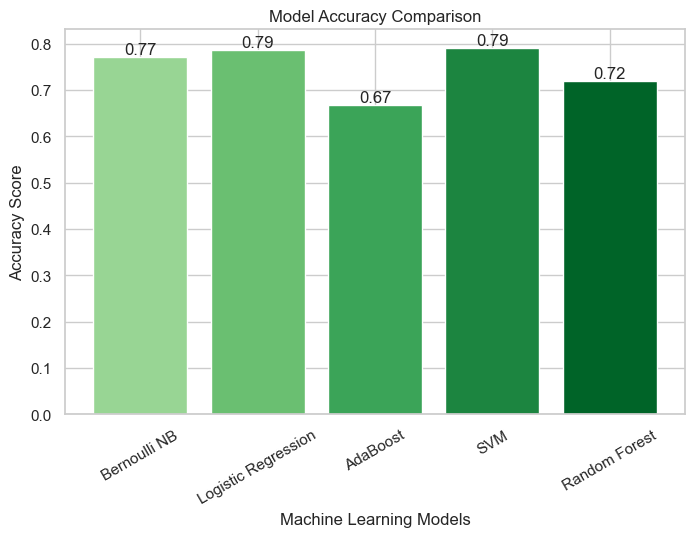

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

models = [
    "Bernoulli NB",
    "Logistic Regression",
    "AdaBoost",
    "SVM",
    "Random Forest"
]

accuracies = [
    0.7711816666666667,
    0.7862975,
    0.6671891666666667,
    0.7911208333333334,
    0.7202091666666667
]

# Green gradient colors
colors = cm.Greens(np.linspace(0.4, 0.9, len(models)))

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=colors)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

# Show accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center',
             va='bottom')

plt.show()

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Confusion Matrix Visualization
</span>
</h3>

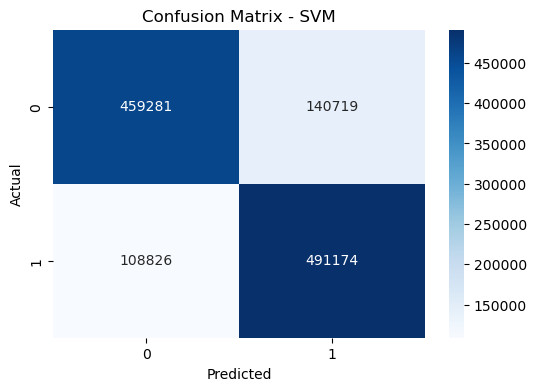

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train, y_train_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

<h3>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Best Model Selection
</span>
</h3>

In [55]:
best_model = model_results.loc[model_results["Accuracy"].idxmax()].reset_index()

print("Best Performing Model:")
print(best_model)

Best Performing Model:
      index                       3
0     Model  Support Vector Machine
1  Accuracy                0.792046


In [47]:
model_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
3,Support Vector Machine,0.792046
1,Logistic Regression,0.785236
0,Bernoulli Naive Bayes,0.771885
4,Random Forest,0.720140
2,AdaBoost,0.614548


<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Conclusion
</span>
</h2>


- Tweet sentiments were analyzed using Natural Language Processing (NLP) techniques.
- The tweet text was cleaned and preprocessed before applying feature extraction.
- TF-IDF vectorization was used to convert textual data into numerical features.
- Five machine learning models (Bernoulli Naive Bayes, Logistic Regression, AdaBoost, SVM, Random Forest) were trained and evaluated.

- Insight: Model comparison using accuracy, confusion matrix, and classification report helped identify the best performing model for sentiment classification.

<h2>
<span style="background-color:#EAEAEA; padding:6px; border-radius:4px;">
Recommendation
</span>
</h2>


- Machine learning models with TF-IDF features can effectively classify tweet sentiments.
- Insight: Using larger and more diverse datasets can improve model generalization.
- Advanced techniques such as LSTM or BERT can capture deeper contextual information in text.
- Hyperparameter tuning and cross-validation can further improve model accuracy and reliability.